In [ ]:
%pip install transformers

## BioBERT Fine-Tuning for Drug Review Classification

**Model**: [BioBERT v1.1](https://huggingface.co/dmis-lab/biobert-v1.1) — BERT-base-cased, continued pre-training on PubMed abstracts + PMC full-text articles.

**Approach**: Minimal text preprocessing (drug name masking only). BioBERT's WordPiece tokenizer handles subword splitting, casing, and special tokens. All layers are fine-tuned with a linear classification head on top.

> **Colab**: upload `balanced_train.csv` and `balanced_test.csv` into a `data/` folder in your workspace.

In [ ]:
import copy
import re
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    get_linear_schedule_with_warmup,
)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla T4


In [3]:
DATA_DIR = "."

df_train = pd.read_csv(f"{DATA_DIR}/balanced_train.csv")
df_test = pd.read_csv(f"{DATA_DIR}/balanced_test.csv")

print(f"Training set: {len(df_train)} records, {df_train['condition'].nunique()} conditions")
print(f"Test set:     {len(df_test)} records, {df_test['condition'].nunique()} conditions")
print(f"\nTrain class distribution:")
print(df_train["condition"].value_counts())

Training set: 29489 records, 10 conditions
Test set:     22070 records, 10 conditions

Train class distribution:
condition
Anxiety            3522
Birth Control      3522
Depression         3522
Pain               3522
Acne               3198
Bipolar Disorde    2693
Insomnia           2639
Weight Loss        2474
Obesity            2325
ADHD               2072
Name: count, dtype: int64


## Preprocessing

Only drug name masking — BERT's WordPiece tokenizer handles casing, punctuation, and subword splitting internally. No stop-word removal or lemmatization needed.

In [4]:
DRUG_PLACEHOLDER = "medication"


def mask_drug_name(text: str, drug_name: str) -> str:
    if pd.isna(drug_name) or pd.isna(text):
        return text if not pd.isna(text) else ""

    pattern = re.compile(r"\b" + re.escape(drug_name) + r"\b", re.IGNORECASE)

    return pattern.sub(DRUG_PLACEHOLDER, text)


df_train["review_masked"] = df_train.apply(
    lambda row: mask_drug_name(row["review"], row["drugName"]),
    axis=1,
)
df_test["review_masked"] = df_test.apply(
    lambda row: mask_drug_name(row["review"], row["drugName"]),
    axis=1,
)

In [5]:
MODEL_NAME = "dmis-lab/biobert-v1.1"

MAX_SEQ_LEN = 256
BATCH_SIZE = 16
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 2
WARMUP_RATIO = 0.1
GRAD_CLIP_NORM = 1.0
ES_PATIENCE = 2

## Tokenization & Data Preparation

BioBERT's WordPiece tokenizer converts raw text into `input_ids` + `attention_mask`. Sequences are truncated/padded to `MAX_SEQ_LEN` tokens.

In [6]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

labels_sorted = sorted(df_train["condition"].unique())
label2id = {label: idx for idx, label in enumerate(labels_sorted)}
id2label = {idx: label for label, idx in label2id.items()}
NUM_CLASSES = len(labels_sorted)
print(f"Classes ({NUM_CLASSES}): {labels_sorted}")

train_texts = df_train["review_masked"].tolist()
train_labels = df_train["condition"].map(label2id).tolist()
test_texts = df_test["review_masked"].tolist()
test_labels = df_test["condition"].map(label2id).tolist()

print(f"Train: {len(train_texts)}, Test: {len(test_texts)}")


class ReviewDataset(Dataset):
    def __init__(
        self,
        texts: list[str],
        labels: list[int],
        tokenizer,
        max_len: int,
    ) -> None:
        self.encodings = tokenizer(
            texts,
            truncation=True,
            padding="max_length",
            max_length=max_len,
            return_tensors="pt",
        )
        self.labels = torch.tensor(labels, dtype=torch.long)

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        return {
            "input_ids": self.encodings["input_ids"][idx],
            "attention_mask": self.encodings["attention_mask"][idx],
            "labels": self.labels[idx],
        }


train_dataset = ReviewDataset(train_texts, train_labels, tokenizer, MAX_SEQ_LEN)
test_dataset = ReviewDataset(test_texts, test_labels, tokenizer, MAX_SEQ_LEN)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE * 2)

print(
    f"\nBatches per epoch — "
    f"Train: {len(train_loader)}, Test: {len(test_loader)}"
)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/462 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Classes (10): ['ADHD', 'Acne', 'Anxiety', 'Bipolar Disorde', 'Birth Control', 'Depression', 'Insomnia', 'Obesity', 'Pain', 'Weight Loss']
Train: 29489, Test: 22070

Batches per epoch — Train: 1844, Test: 690


In [7]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=NUM_CLASSES,
    id2label=id2label,
    label2id=label2id,
)
model.to(DEVICE)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

pytorch_model.bin:   0%|          | 0.00/433M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

BertForSequenceClassification LOAD REPORT from: dmis-lab/biobert-v1.1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Total parameters:     108,317,962
Trainable parameters: 108,317,962


## Training

AdamW with differential weight decay (none for bias and LayerNorm). Linear LR warmup for the first 10% of steps, then linear decay to zero. Early stopping on validation loss.

In [8]:
no_decay = ("bias", "LayerNorm.weight")
optimizer_grouped_parameters = [
    {
        "params": [
            p for n, p in model.named_parameters()
            if not any(nd in n for nd in no_decay)
        ],
        "weight_decay": WEIGHT_DECAY,
    },
    {
        "params": [
            p for n, p in model.named_parameters()
            if any(nd in n for nd in no_decay)
        ],
        "weight_decay": 0.0,
    },
]

optimizer = torch.optim.AdamW(optimizer_grouped_parameters, lr=LEARNING_RATE)

total_steps = len(train_loader) * NUM_EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps,
)

print(f"Total steps: {total_steps}, Warmup steps: {warmup_steps}")

best_val_loss = float("inf")
best_model_state = None
patience_counter = 0

history: dict[str, list[float]] = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
}

for epoch in range(NUM_EPOCHS):
    t0 = time.time()

    # ---- Train ----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Train]")
    for batch in pbar:
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)

        outputs.loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP_NORM)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        bs = batch["labels"].size(0)
        running_loss += outputs.loss.item() * bs
        preds = outputs.logits.argmax(dim=-1)
        correct += (preds == batch["labels"]).sum().item()
        total += bs

        pbar.set_postfix(
            loss=f"{running_loss / total:.4f}",
            acc=f"{correct / total:.4f}",
        )

    train_loss = running_loss / total
    train_acc = correct / total

    # ---- Validate ----
    # model.eval()
    # running_loss = 0.0
    # correct = 0
    # total = 0

    # with torch.no_grad():
    #     for batch in tqdm(val_loader, desc=f"Epoch {epoch + 1}/{NUM_EPOCHS} [Val]"):
    #         batch = {k: v.to(DEVICE) for k, v in batch.items()}
    #         outputs = model(**batch)

    #         bs = batch["labels"].size(0)
    #         running_loss += outputs.loss.item() * bs
    #         preds = outputs.logits.argmax(dim=-1)
    #         correct += (preds == batch["labels"]).sum().item()
    #         total += bs

    # val_loss = running_loss / total
    # val_acc = correct / total

    history["train_loss"].append(train_loss)
    # history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    # history["val_acc"].append(val_acc)

    elapsed = time.time() - t0
    print(
        f"Epoch {epoch + 1}/{NUM_EPOCHS} | "
        f"Train Loss: {train_loss:.4f}  Acc: {train_acc:.4f} | "
        # f"Val Loss: {val_loss:.4f}  Acc: {val_acc:.4f} | "
        f"{elapsed:.0f}s"
    )

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     best_model_state = copy.deepcopy(model.state_dict())
    #     patience_counter = 0
    #     print(f"  -> New best model (val_loss={val_loss:.4f})")
    # else:
    #     patience_counter += 1
    #     if patience_counter >= ES_PATIENCE:
    #         print(f"  Early stopping at epoch {epoch + 1}")
    #         break

Total steps: 3688, Warmup steps: 368


Epoch 1/2 [Train]:   0%|          | 0/1844 [00:00<?, ?it/s]

Epoch 1/2 | Train Loss: 0.8245  Acc: 0.7013 | 1268s


Epoch 2/2 [Train]:   0%|          | 0/1844 [00:00<?, ?it/s]

Epoch 2/2 | Train Loss: 0.4336  Acc: 0.8308 | 1268s


TypeError: Expected state_dict to be dict-like, got <class 'NoneType'>.

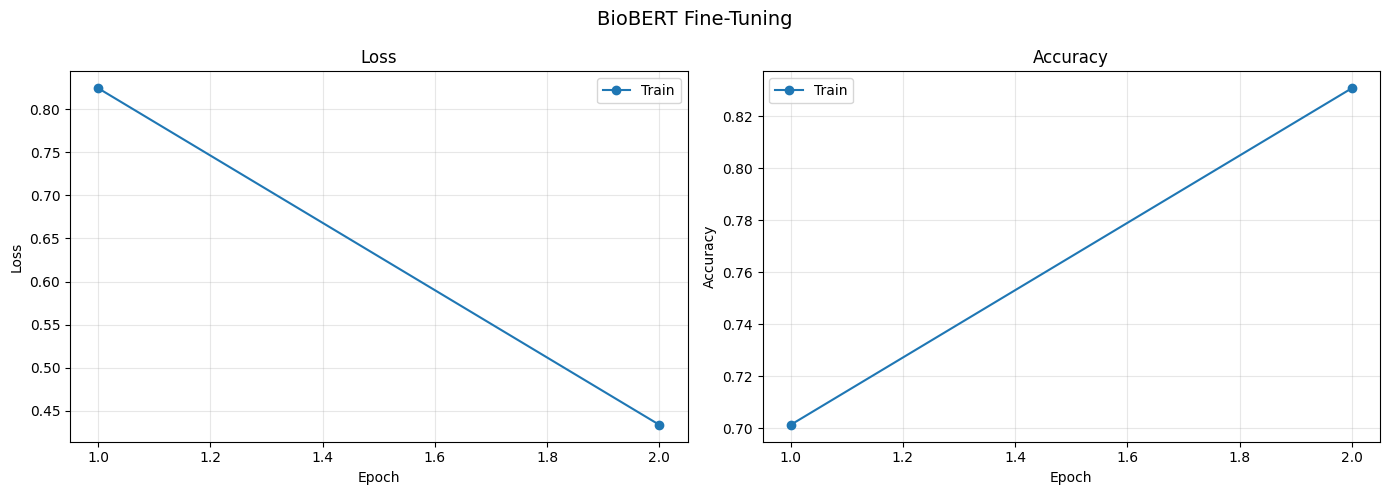

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history["train_loss"]) + 1)

axes[0].plot(epochs_range, history["train_loss"], "o-", label="Train")
# axes[0].plot(epochs_range, history["val_loss"], "o-", label="Validation")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history["train_acc"], "o-", label="Train")
# axes[1].plot(epochs_range, history["val_acc"], "o-", label="Validation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

fig.suptitle("BioBERT Fine-Tuning", fontsize=14)
plt.tight_layout()
plt.show()

## Evaluation on Test Set

In [10]:
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        batch = {k: v.to(DEVICE) for k, v in batch.items()}
        outputs = model(**batch)
        preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.4f}\n")
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=labels_sorted,
        digits=4,
    )
)

Testing:   0%|          | 0/690 [00:00<?, ?it/s]

Test Accuracy: 0.8778

                 precision    recall  f1-score   support

           ADHD     0.9008    0.8898    0.8953       980
           Acne     0.8500    0.9539    0.8990      1693
        Anxiety     0.7538    0.8008    0.7766      1747
Bipolar Disorde     0.7069    0.8002    0.7507      1236
  Birth Control     0.9897    0.9460    0.9673      8402
     Depression     0.8026    0.7498    0.7753      2798
       Insomnia     0.8568    0.8971    0.8765      1127
        Obesity     0.5890    0.5996    0.5943      1054
           Pain     0.9141    0.9378    0.9258      1896
    Weight Loss     0.6332    0.6148    0.6238      1137

       accuracy                         0.8628     22070
      macro avg     0.7997    0.8190    0.8084     22070
   weighted avg     0.8660    0.8628    0.8636     22070



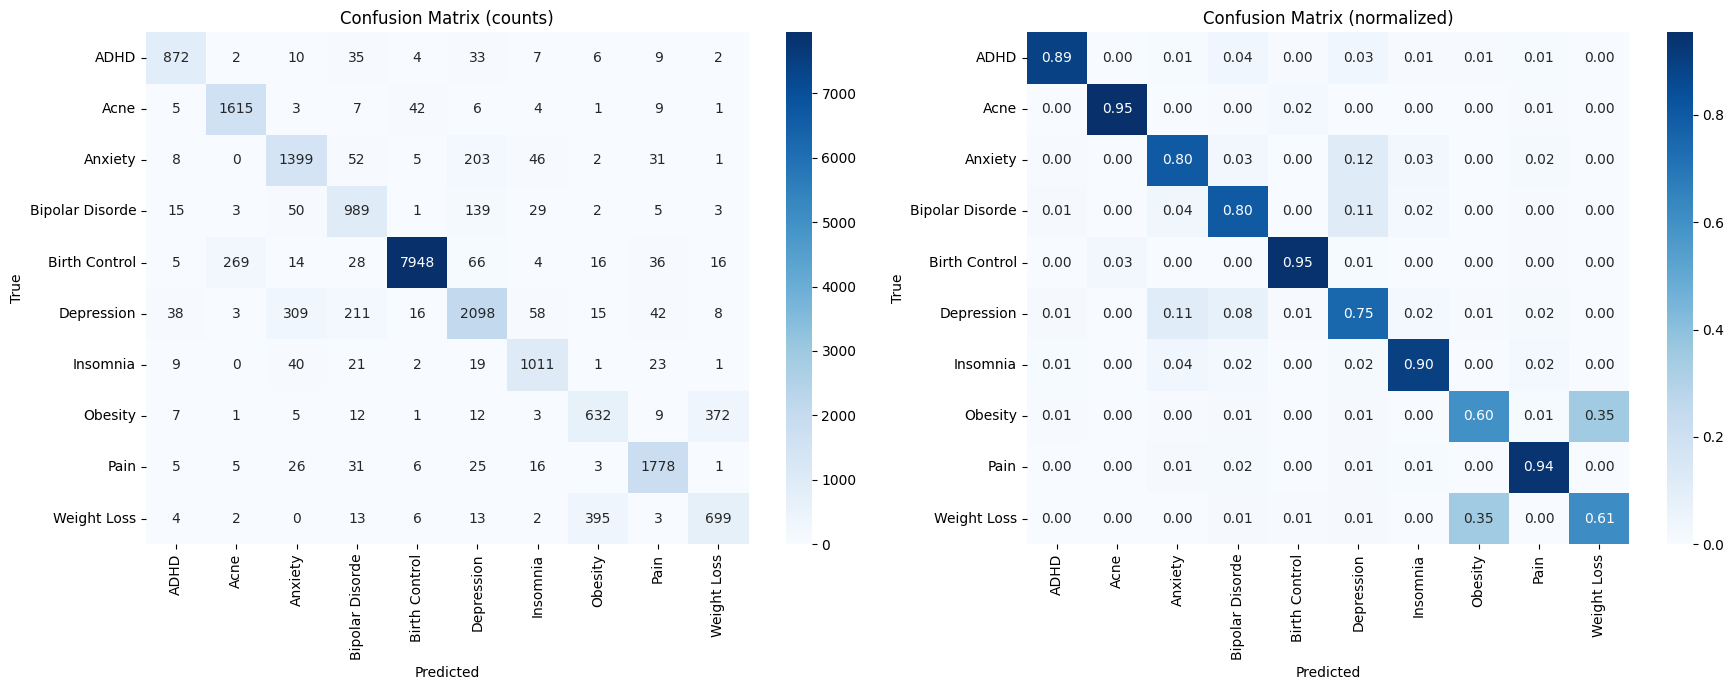

In [11]:
cm = confusion_matrix(all_labels, all_preds)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    ax=axes[0],
)
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("True")
axes[0].set_title("Confusion Matrix (counts)")

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=labels_sorted,
    yticklabels=labels_sorted,
    ax=axes[1],
)
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("True")
axes[1].set_title("Confusion Matrix (normalized)")

plt.tight_layout()
plt.show()

In [ ]:
output_path = "biobert_drug_review_model.pth"

torch.save(model.state_dict(), output_path)

print(f"Model saved to {output_path}")

In [12]:
model.save_pretrained("./my-bert-model")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [ ]:
loaded_model = AutoModelForSequenceClassification.from_pretrained("./my-bert-model")
loaded_model.to(DEVICE)

In [16]:
def predict_condition(text: str, model, tokenizer, id2label, device) -> str:
    # Tokenize the input text
    inputs = tokenizer(
        text,
        truncation=True,
        padding="max_length",
        max_length=MAX_SEQ_LEN,
        return_tensors="pt",
    )

    # Move inputs to the correct device
    input_ids = inputs["input_ids"].to(device)
    attention_mask = inputs["attention_mask"].to(device)

    # Set model to evaluation mode
    model.eval()

    # Make prediction
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits

    # Get predicted class ID
    predicted_class_id = torch.argmax(logits, dim=-1).item()

    # Map class ID to label
    predicted_label = id2label[predicted_class_id]

    return predicted_label

# Example usage:
example_text = "This medication significantly reduced my anxiety attacks and helped me sleep better."
predicted_condition = predict_condition(example_text, loaded_model, tokenizer, id2label, DEVICE)
print(f"Predicted condition for the text: '{example_text}' is '{predicted_condition}'")

example_text_2 = "I've been using this birth control for years, and it's been very effective with no major side effects."
predicted_condition_2 = predict_condition(example_text_2, loaded_model, tokenizer, id2label, DEVICE)
print(f"Predicted condition for the text: '{example_text_2}' is '{predicted_condition_2}'")

Predicted condition for the text: 'This medication significantly reduced my anxiety attacks and helped me sleep better.' is 'Anxiety'
Predicted condition for the text: 'I've been using this birth control for years, and it's been very effective with no major side effects.' is 'Birth Control'
